In [1]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot

# Libraries linear regression model
from statsmodels.formula.api import ols
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# Libraries for preparing data
from sklearn.model_selection import train_test_split

# Libraries for data preprocessing
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

# Import the required function
from scipy.stats import pearsonr

# Function for calculating Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Performs White’s test for heteroscedasticity
from statsmodels.stats.diagnostic import het_white

# Formats test results cleanly
from statsmodels.compat import lzip

# Provides access to additional diagnostic tools like sms.het_breuschpagan.
import statsmodels.stats.api as sms

# Combines functions from matplotlib and numpy
import pylab

# Gives you access to statistical functions
import scipy.stats as stats

# Allows you run cross‑validation to get evaluation scores
from sklearn.model_selection import cross_val_score

# Libraries for evaluating model performance
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

try:
    from sklearn.metrics import mean_absolute_percentage_error
except ImportError:
    mean_absolute_percentage_error = None

# Set the working directory to the location of the dataset
import os

In [2]:
# Read in csv and name the dataframe 'df'
df = pd.read_csv("C:\\Users\\goati\\prolific_g.o.a.t\\machine_learning_project\\Boston.csv")
df.head()



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [3]:
# Check for duplicate entries
df.duplicated().sum()

np.int64(0)

In [4]:
# Inspect the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [5]:
# Univariate Analysis
# Print the statistical summary
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


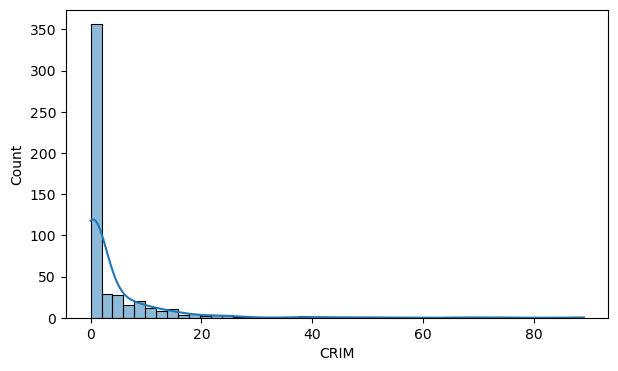

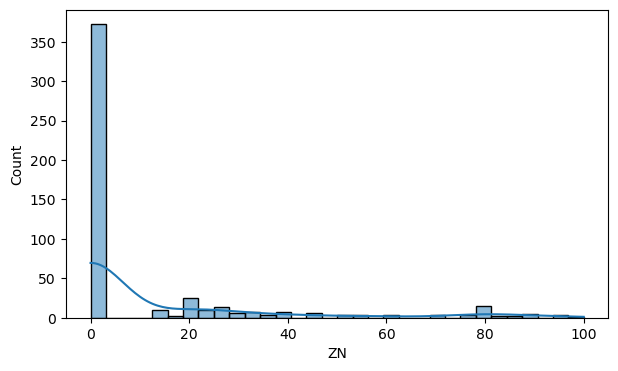

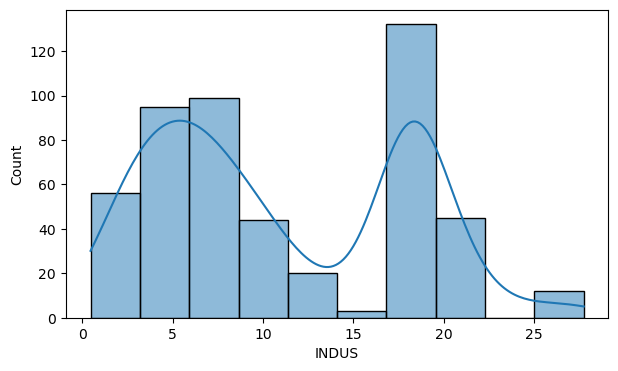

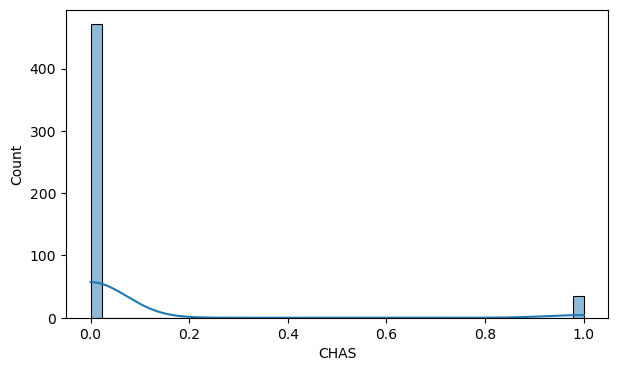

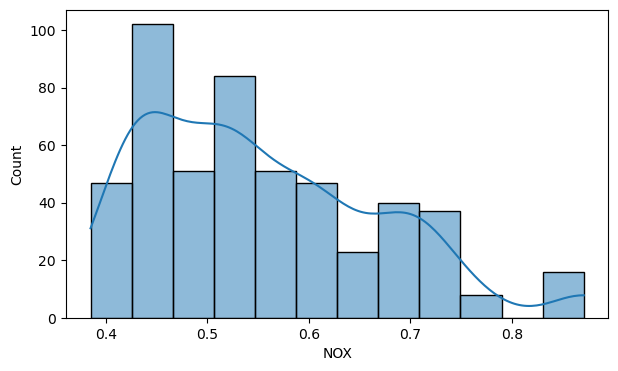

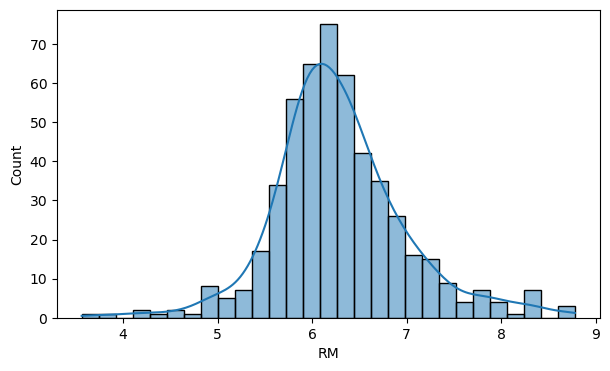

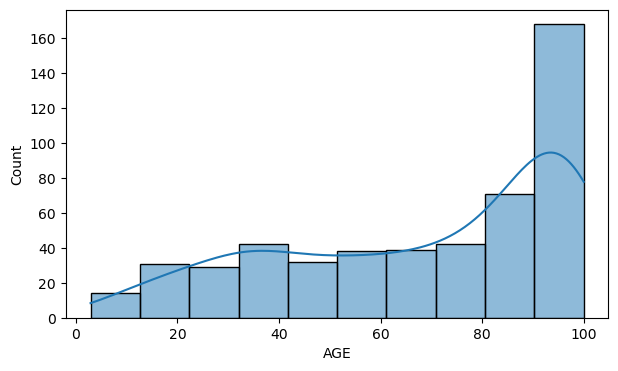

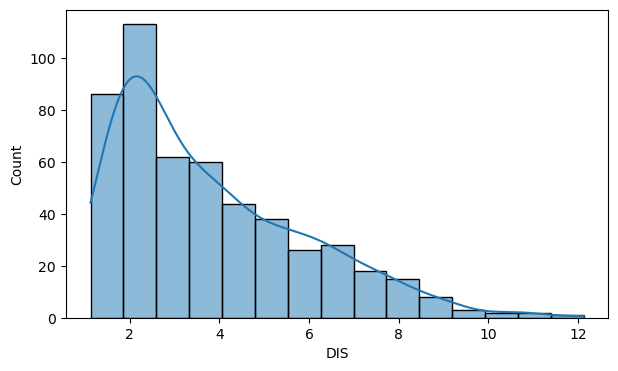

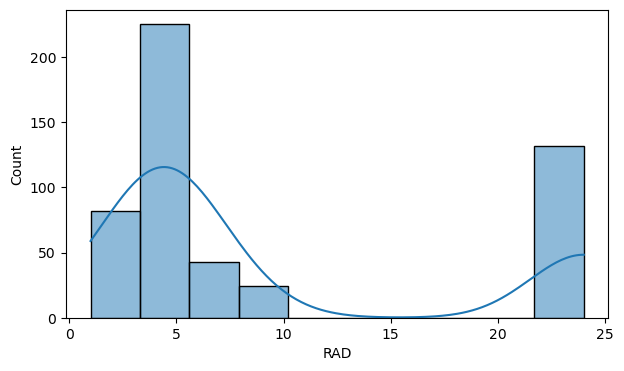

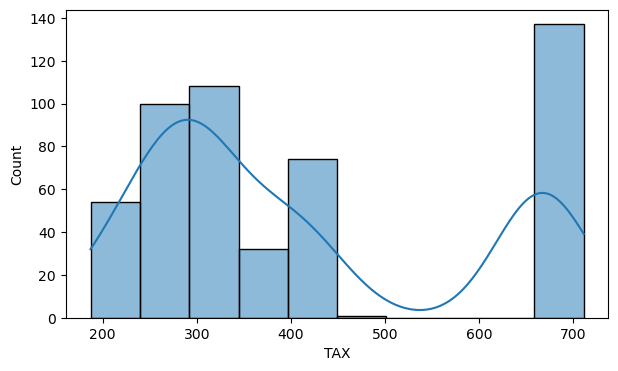

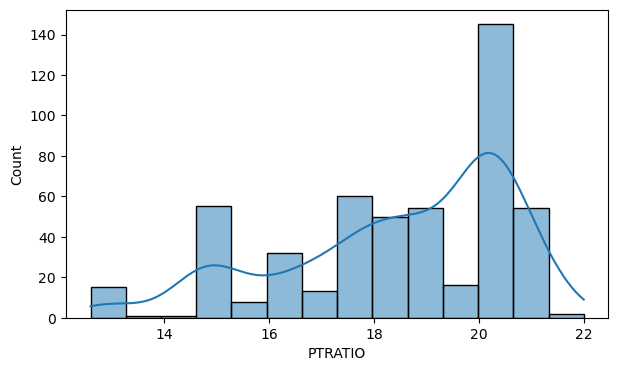

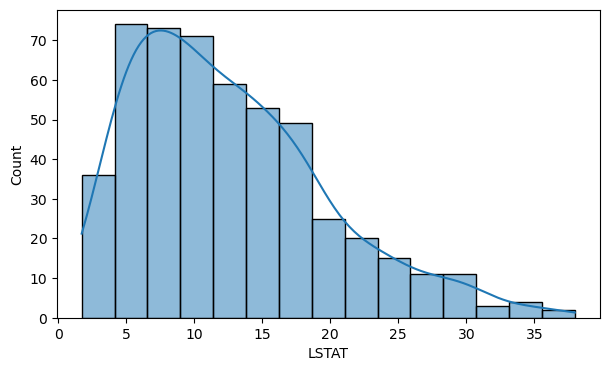

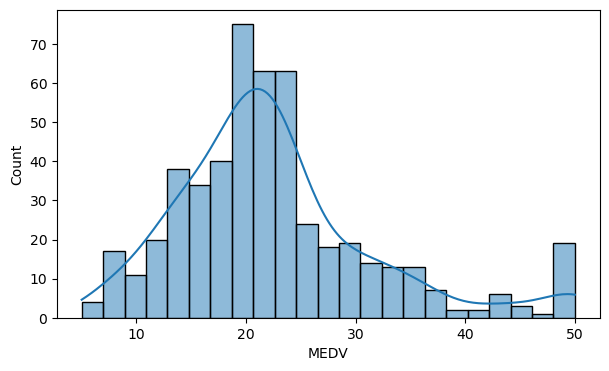

In [6]:
# Plotting all columns to evaluate there distributions
for i in df.columns:
    plt.figure(figsize = (7, 4))
    sns.histplot(data = df, x = i, kde = True)
    plt.show()

<Axes: xlabel='MEDV_log', ylabel='Count'>

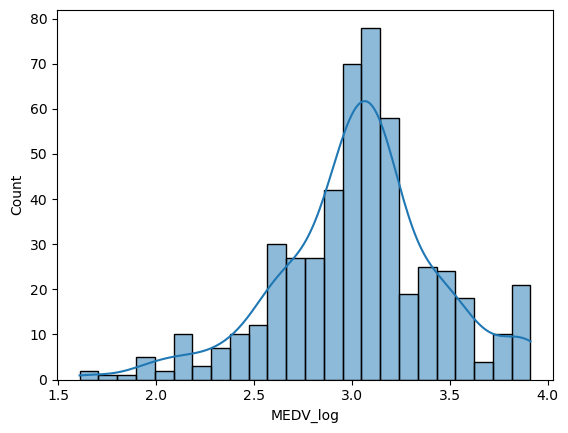

In [7]:
# Create a new column with a log‑transformed version of MEDV
df['MEDV_log'] = np.log(df['MEDV'])

# Plot the log‑transformed target 
sns.histplot(data = df, x = 'MEDV_log', kde = True)

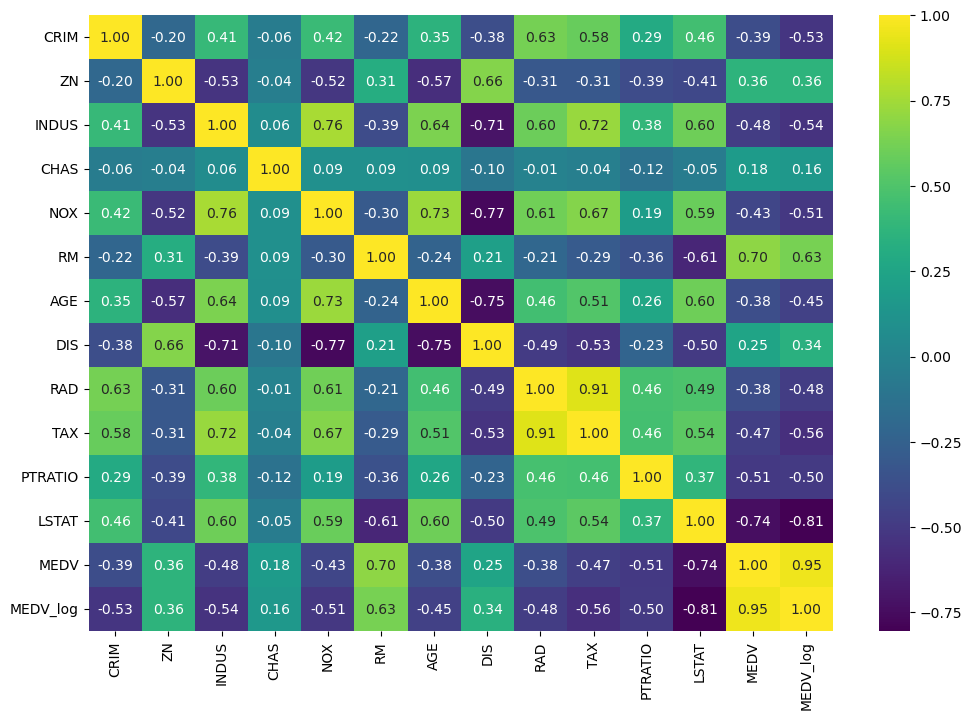

In [8]:
# Bivariate Analysis
# Plot a correlation‑heatmap
plt.figure(figsize = (12, 8))
cmap = "viridis"
sns.heatmap(df.corr(), annot = True, fmt = '.2f', cmap = cmap)
plt.show()

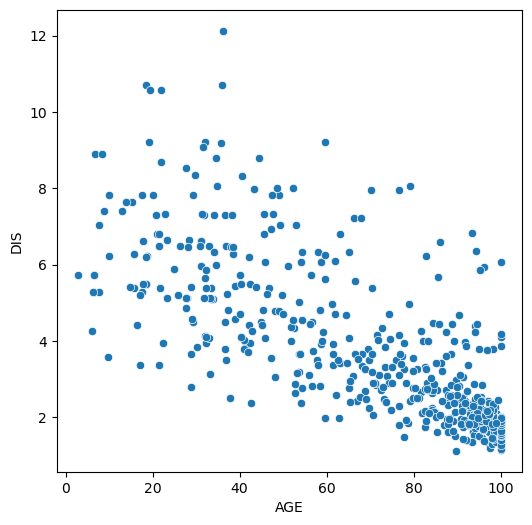

In [9]:
# Create a scatterplot to visualize the relationship between AGE and DIS
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'AGE', y = 'DIS', data = df)
plt.show()

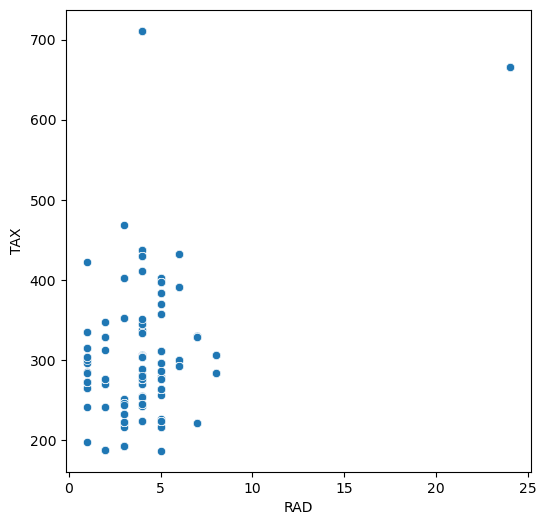

In [10]:
# Create a scatterplot to visualize the relationship between RAD and TAX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'RAD', y = 'TAX', data = df)
plt.show()

In [11]:
# Remove the data corresponding to high tax rate
df1 = df[df['TAX'] < 600]

# Calculate the correlation
print('The correlation between TAX and RAD is', pearsonr(df1['TAX'], df1['RAD'])[0])

The correlation between TAX and RAD is 0.249757313314292


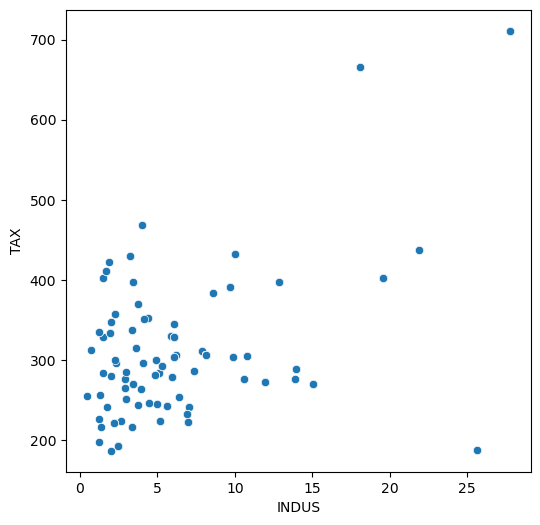

In [12]:
# Create a scatterplot to visualize the relationship between INDUS and TAX
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'INDUS', y = 'TAX', data = df)
plt.show()

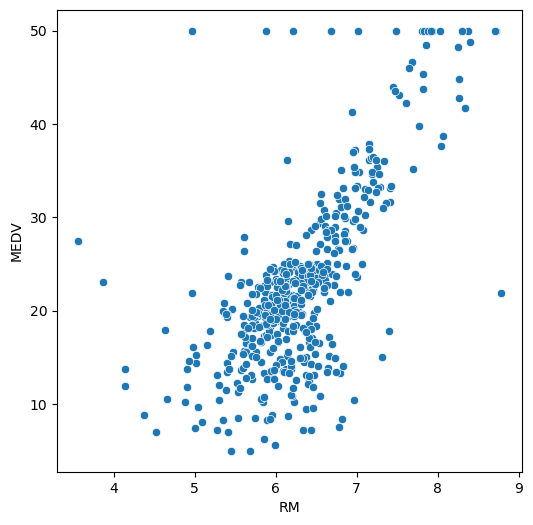

In [13]:
# Create a scatterplot to visualize the relationship between RM and MEDV
plt.figure(figsize = (6, 6))

sns.scatterplot(x = 'RM', y = 'MEDV', data = df)

plt.show()

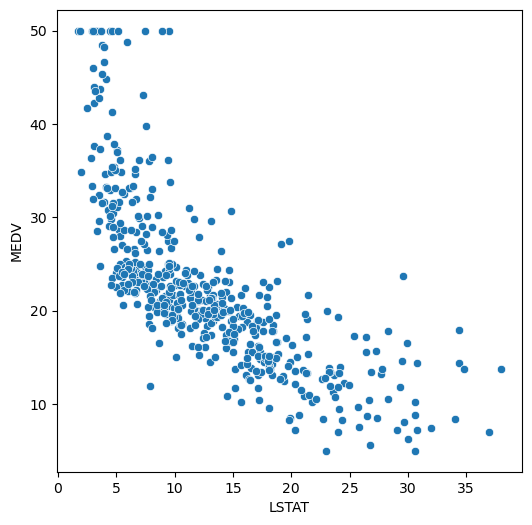

In [14]:
# Create a scatterplot to visualize the relationship between LSTAT and MEDV
plt.figure(figsize = (6, 6))
sns.scatterplot(x = 'LSTAT', y = 'MEDV', data = df)
plt.show()

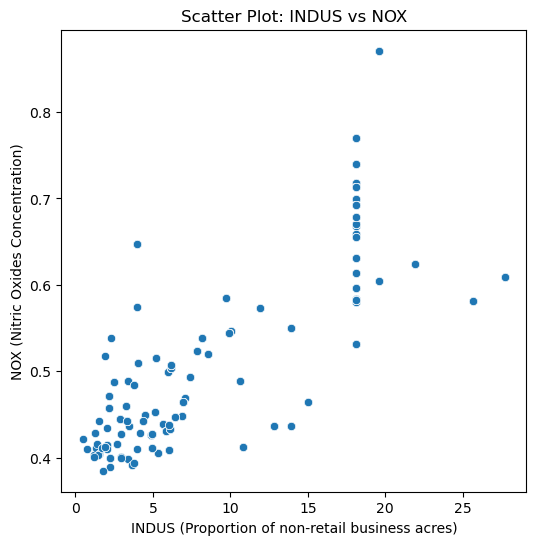

In [15]:
# Scatterplot to visualize the relationship between INDUS and NOX
plt.figure(figsize = (6, 6))

sns.scatterplot(data=df, x='INDUS', y='NOX')
plt.xlabel('INDUS (Proportion of non-retail business acres)')
plt.ylabel('NOX (Nitric Oxides Concentration)')
plt.title('Scatter Plot: INDUS vs NOX')
plt.show()

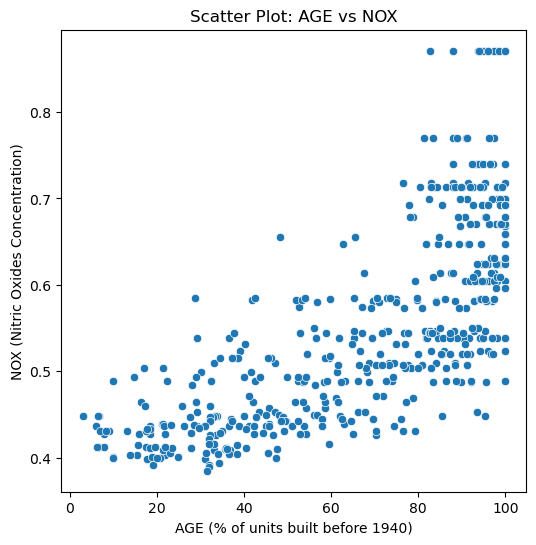

In [16]:
# Scatterplot to visualize the relationship between AGE and NOX
plt.figure(figsize = (6, 6))

sns.scatterplot(data=df, x='AGE', y='NOX')
plt.xlabel('AGE (% of units built before 1940)')
plt.ylabel('NOX (Nitric Oxides Concentration)')
plt.title('Scatter Plot: AGE vs NOX')

plt.show()

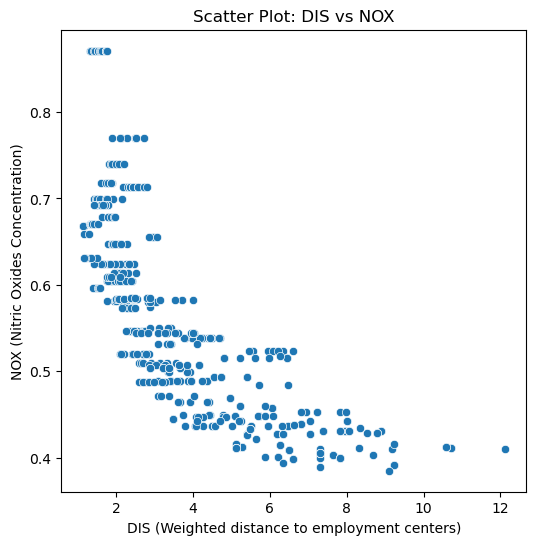

In [17]:
# Scatterplot to visualize the relationship between DIS and NOX
plt.figure(figsize = (6, 6))

sns.scatterplot(data=df, x='DIS', y='NOX')
plt.xlabel('DIS (Weighted distance to employment centers)')
plt.ylabel('NOX (Nitric Oxides Concentration)')
plt.title('Scatter Plot: DIS vs NOX')

plt.show()

In [18]:
# Display dataset
display(df)

# Split the dataset
# Separate the dependent variable and indepedent variables
Y = df['MEDV_log']
X = df.drop(columns = {'MEDV', 'MEDV_log'})

# Add the intercept term
X = sm.add_constant(X)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,MEDV_log
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,3.178054
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,3.072693
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,3.546740
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,3.508556
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,3.589059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,3.109061
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,3.025291
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,3.173878
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,3.091042


In [19]:
# splitting the data in 70:30 ratio of train to test data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.30, random_state = 1)

In [20]:
# Check for Multicollinearity
# Function to check VIF
def checking_vif(train):
    vif = pd.DataFrame()
    vif["feature"] = train.columns

    # Calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(train.values, i) for i in range(len(train.columns))
    ]
    return vif

print(checking_vif(X_train))

    feature         VIF
0     const  535.372593
1      CRIM    1.924114
2        ZN    2.743574
3     INDUS    3.999538
4      CHAS    1.076564
5       NOX    4.396157
6        RM    1.860950
7       AGE    3.150170
8       DIS    4.355469
9       RAD    8.345247
10      TAX   10.191941
11  PTRATIO    1.943409
12    LSTAT    2.861881


In [21]:
# Create the model after dropping TAX
X_train = X_train.drop('TAX', axis=1)

# Check for VIF
print(checking_vif(X_train))

    feature         VIF
0     const  532.025529
1      CRIM    1.923159
2        ZN    2.483399
3     INDUS    3.270983
4      CHAS    1.050708
5       NOX    4.361847
6        RM    1.857918
7       AGE    3.149005
8       DIS    4.333734
9       RAD    2.942862
10  PTRATIO    1.909750
11    LSTAT    2.860251


In [22]:
# Create the model
model1 = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Get the model summary
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MEDV_log   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     103.3
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          1.40e-101
Time:                        20:59:41   Log-Likelihood:                 76.596
No. Observations:                 354   AIC:                            -129.2
Df Residuals:                     342   BIC:                            -82.76
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6324      0.243     19.057      0.000       4.154       5.111
CRIM          -0.0128      0.002     -7.445      0.000      -0.016      -0.009
ZN             0.0010      0.001      1.425      0.155      -0.000       0.002
INDUS         -0.0004      0.003     -0.148      0.883      -0.006       0.005
CHAS           0.1196      0.039      3.082      0.002       0.043       0.196
NOX           -1.0598      0.187     -5.675      0.000      -1.427      -0.692
RM             0.0532      0.021      2.560      0.011       0.012       0.094
AGE            0.0003      0.001      0.461      0.645      -0.001       0.002
DIS           -0.0503      0.010     -4.894      0.000      -0.071      -0.030
RAD            0.0076      0.002      3.699      0.000       0.004       0.012
PTRATIO       -0.0452      0.007     -6.659      0.000      -0.059      -0.032
LSTAT         -0.0298      0.002    -12.134      0.000      -0.035      -0.025
==============================================================================
Omnibus:                       30.699   Durbin-Watson:                   1.923
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               83.718
Skew:                           0.372   Prob(JB):                     6.62e-19
Kurtosis:                       5.263   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [23]:
# Create the model after dropping columns 'MEDV', 'MEDV_log', 'TAX', 'ZN', 'AGE', 'INDUS' from df DataFrame
Y = df['MEDV_log']
X = df.drop(['MEDV', 'MEDV_log', 'TAX', 'ZN', 'AGE', 'INDUS'], axis=1)
X = sm.add_constant(X)

# Splitting the data in 70:30 ratio of train to test data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.30 , random_state = 1)

# Create the model
model2 = sm.OLS(y_train, X_train).fit()

# Get the model summary
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               MEDV_log   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.762
Method:                 Least Squares   F-statistic:                     142.1
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          2.61e-104
Time:                        20:59:42   Log-Likelihood:                 75.486
No. Observations:                 354   AIC:                            -133.0
Df Residuals:                     345   BIC:                            -98.15
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6494      0.242     19.242      0.000       4.174       5.125
CRIM          -0.0125      0.002     -7.349      0.000      -0.016      -0.009
CHAS           0.1198      0.039      3.093      0.002       0.044       0.196
NOX           -1.0562      0.168     -6.296      0.000      -1.386      -0.726
RM             0.0589      0.020      2.928      0.004       0.019       0.098
DIS           -0.0441      0.008     -5.561      0.000      -0.060      -0.028
RAD            0.0078      0.002      3.890      0.000       0.004       0.012
PTRATIO       -0.0485      0.006     -7.832      0.000      -0.061      -0.036
LSTAT         -0.0293      0.002    -12.949      0.000      -0.034      -0.025
==============================================================================
Omnibus:                       32.514   Durbin-Watson:                   1.925
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               87.354
Skew:                           0.408   Prob(JB):                     1.07e-19
Kurtosis:                       5.293   Cond. No.                         690.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
# Linear regression assumptions
# Check the 'mean' of the 'residuals'
residuals = y_train - model2.fittedvalues
np.mean(residuals)

np.float64(-5.569932462526209e-15)

In [25]:
# Test split the data into two groups: "F statistic", "p-value" 
# Based the predictors and fits separate regressions for both groups
# And compares the variance of residuals
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(y_train, X_train)
lzip(name, test)

[('F statistic', np.float64(1.0835082923425283)),
 ('p-value', np.float64(0.301901200676687))]

In [26]:
# Test split the data into two groups: "F statistic", "p-value" 
# Based the predictors and fits separate regressions for both groups
# And compares the variance of residuals
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(y_train, X_train)
lzip(name, test)

[('F statistic', np.float64(1.0835082923425283)),
 ('p-value', np.float64(0.301901200676687))]

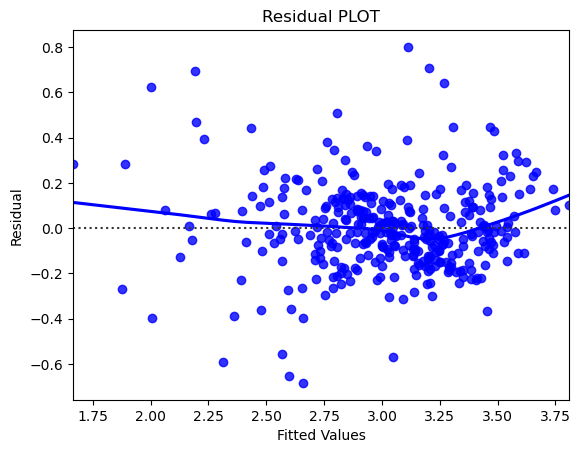

In [27]:
# Linearity of variables
# Predicted values
fitted = model2.fittedvalues

# sns.set_style("whitegrid")
sns.residplot(x=fitted, y=residuals, color="blue", lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual PLOT")
plt.show()

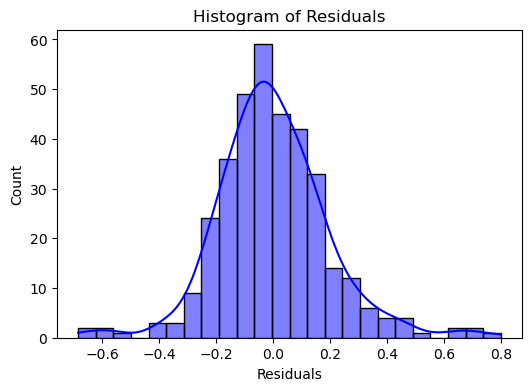

In [28]:
# Normality of error terms
# Plot histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color="blue")
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

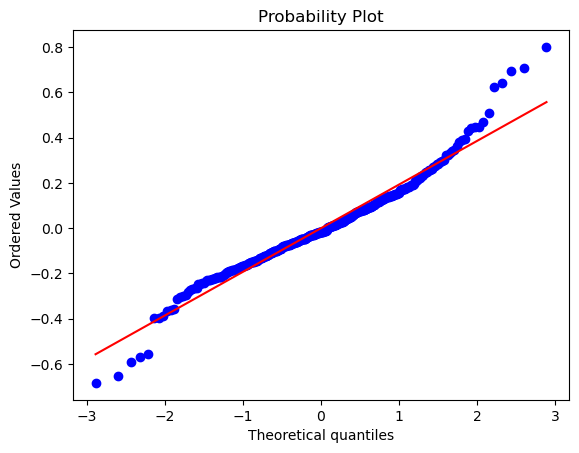

In [29]:
# Plot q-q plot of residuals
stats.probplot(residuals, dist = "norm", plot = pylab)
plt.show()

In [30]:
# Check the performance of the model on the train and test data set
# RMSE
def rmse(predictions, targets):
    return np.sqrt(((targets - predictions) ** 2).mean())


# MAPE
def mape(predictions, targets):
    return np.mean(np.abs((targets - predictions)) / targets) * 100


# MAE
def mae(predictions, targets):
    return np.mean(np.abs((targets - predictions)))


# Model Performance on test and train data
def model_pref(olsmodel, x_train, x_test):

    # In-sample Prediction
    y_pred_train = olsmodel.predict(x_train)
    y_observed_train = y_train

    # Prediction on test data
    y_pred_test = olsmodel.predict(x_test)
    y_observed_test = y_test

    print(
        pd.DataFrame(
            {
                "Data": ["Train", "Test"],
                "RMSE": [
                    rmse(y_pred_train, y_observed_train),
                    rmse(y_pred_test, y_observed_test),
                ],
                "MAE": [
                    mae(y_pred_train, y_observed_train),
                    mae(y_pred_test, y_observed_test),
                ],
                "MAPE": [
                    mape(y_pred_train, y_observed_train),
                    mape(y_pred_test, y_observed_test),
                ],
            }
        )
    )


# Checking model performance
model_pref(model2, X_train, X_test)  

    Data      RMSE       MAE      MAPE
0  Train  0.195504  0.143686  4.981813
1   Test  0.198045  0.151284  5.257965


In [31]:
# Get the final model of coefficients in a pandas DataFrame 
# The column 'Feature' will include all of the features 
# And the column 'Coefs' will include all the corresponding Coefs
coef = model2.params
final_coefs_model = coef
pd.DataFrame({'Feature' : coef.index, 'Coefs' : coef.values})
print(final_coefs_model)

const      4.649386
CRIM      -0.012500
CHAS       0.119773
NOX       -1.056225
RM         0.058907
DIS       -0.044069
RAD        0.007848
PTRATIO   -0.048504
LSTAT     -0.029277
dtype: float64


In [32]:
# Get the final model of coefficients in a pandas DataFrame 
# The column 'Feature' will include all of the features 
# And the column 'Coefs' will include all the corresponding Coefs
coef = model2.params
final_coefs_model = coef
pd.DataFrame({'Feature' : coef.index, 'Coefs' : coef.values})
print(final_coefs_model)

const      4.649386
CRIM      -0.012500
CHAS       0.119773
NOX       -1.056225
RM         0.058907
DIS       -0.044069
RAD        0.007848
PTRATIO   -0.048504
LSTAT     -0.029277
dtype: float64


Correlation with MEDV:


MEDV        1.000000
MEDV_log    0.953155
RM          0.695360
ZN          0.360445
DIS         0.249929
CHAS        0.175260
AGE        -0.376955
RAD        -0.381626
CRIM       -0.388305
NOX        -0.427321
TAX        -0.468536
INDUS      -0.483725
PTRATIO    -0.507787
LSTAT      -0.737663
Name: MEDV, dtype: float64


model2 coefficients and p-values:


,Feature,Coefficient,P_Value
0,const,4.649386,1.419021e-56
1,CRIM,-0.012500,1.462904e-12
2,CHAS,0.119773,2.140473e-03
3,NOX,-1.056225,9.266261e-10
4,RM,0.058907,3.643558e-03
5,DIS,-0.044069,5.387813e-08
6,RAD,0.007848,1.202161e-04
7,PTRATIO,-0.048504,5.990915e-14
8,LSTAT,-0.029277,1.576134e-31



VIF table:


...

,Feature,Coef,P_Value
0,const,35.900828,2.283637e-10
1,CRIM,-0.122778,5.854088e-04
2,CHAS,3.277127,8.134526e-04
3,NOX,-21.017697,1.250759e-07
4,RM,4.421351,3.077750e-20
5,DIS,-1.252457,3.633034e-11
6,RAD,0.084296,6.579478e-02
7,PTRATIO,-1.006143,8.014214e-13
8,LSTAT,-0.538913,4.561842e-21



Selected model coefficients:


,Feature,Coef,P_Value
0,const,15.197796,6.503641e-04
1,RM,4.958907,9.789392e-23
2,LSTAT,-0.548730,4.197779e-20
3,PTRATIO,-0.871256,3.345315e-11
4,NOX,-1.663130,5.499368e-01



Engineered model coefficients:


,Feature,Coef,P_Value
0,const,79.194420,4.268595e-04
1,RM,-16.461895,5.201485e-03
2,LSTAT,-0.084002,8.940116e-01
3,PTRATIO,-0.596336,1.731945e-07
4,NOX,-1.082948,6.629902e-01
5,RM_sq,1.724871,1.634322e-05
6,LSTAT_sq,0.011754,3.781558e-02
7,RM_LSTAT,-0.157973,5.172095e-02


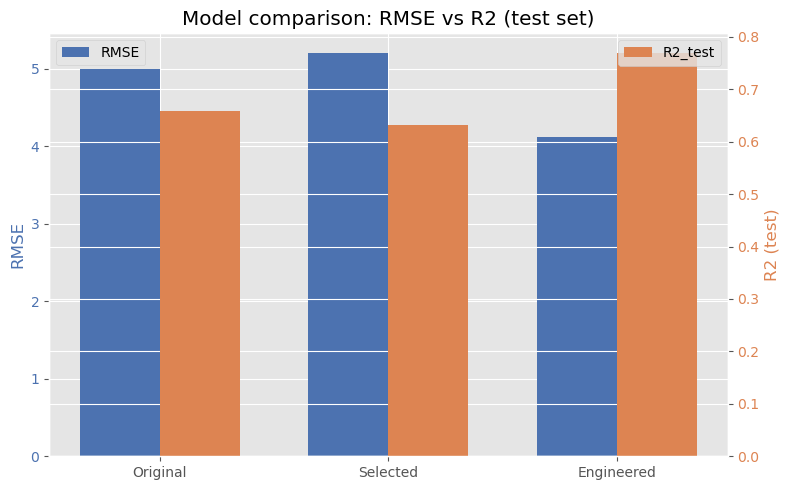


Automated interpretation:
- Original — RMSE 4.9982, MAPE 0.1742, R² 0.6593.
- Selected — RMSE 5.1941, MAPE 0.1753, R² 0.6321.
- Engineered — RMSE 4.1234, MAPE 0.1411, R² 0.7682.
Engineered model improved RMSE.
Selected model did not improve RMSE.

Next steps: run k-fold CV, inspect residuals, and consider Ridge/Lasso.


In [33]:
# --- Robust metric helpers ----------------------------------------------------

def safe_rmse(y_true, y_pred):
    """RMSE with sklearn fallback handling."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_mape(y_true, y_pred):
    """MAPE with sklearn fallback + zero-division protection."""
    try:
        from sklearn.metrics import mean_absolute_percentage_error
        return mean_absolute_percentage_error(y_true, y_pred)
    except Exception:
        denom = np.where(y_true == 0, 1e-8, y_true)
        return np.mean(np.abs((y_true - y_pred) / denom))


# --- OLS evaluation helper ----------------------------------------------------

def evaluate_statsmodels_ols(df, target_col, features, test_size=0.2, random_state=42):
    """Fit statsmodels OLS on a train/test split and return metrics + model."""
    X = df[features]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    X_train_sm = sm.add_constant(X_train, has_constant='add')
    X_test_sm  = sm.add_constant(X_test,  has_constant='add')

    model = sm.OLS(y_train, X_train_sm).fit()
    y_pred = model.predict(X_test_sm)

    # Clean non-finite values
    y_true = np.asarray(y_test).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true, y_pred = y_true[mask], y_pred[mask]

    return {
        'rmse': safe_rmse(y_true, y_pred),
        'mape': safe_mape(y_true, y_pred),
        'r2_test': r2_score(y_true, y_pred),
        'model': model,
        'features': features
    }


# --- 1) Feature selection diagnostics -----------------------------------------

# 1a: Correlation with target
corr_with_target = df.corr()['MEDV'].sort_values(ascending=False)
print("Correlation with MEDV:")
display(corr_with_target)

# 1b: model2 coefficients (if available)
try:
    coef_table = pd.DataFrame({
        'Feature': model2.params.index,
        'Coefficient': model2.params.values,
        'P_Value': model2.pvalues.values
    })
    print("\nmodel2 coefficients and p-values:")
    display(coef_table)
except Exception:
    print("\nmodel2 not available; skipping coefficient table.")

# 1c: VIF for multicollinearity
X_vif = df.drop(columns=['MEDV'])
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("\nVIF table:")
display(vif_df)


# --- 2) Feature engineering ----------------------------------------------------

engineered_defs = {
    'RM_sq':      lambda d: d['RM'] ** 2,
    'LSTAT_sq':   lambda d: d['LSTAT'] ** 2,
    'RM_LSTAT':   lambda d: d['RM'] * d['LSTAT'],
    'NOX_DIS':    lambda d: d['NOX'] * d['DIS'],
    'CRIM_log':   lambda d: np.log1p(d['CRIM']),
    'DIS_log':    lambda d: np.log1p(d['DIS'])
}

for col, func in engineered_defs.items():
    if col not in df.columns:
        df[col] = func(df)


# --- 3) Feature sets -----------------------------------------------------------

try:
    orig_features = [f for f in model2.params.index if f.lower() != 'const']
except Exception:
    orig_features = [c for c in df.columns if c != 'MEDV']

selected_features = ['RM', 'LSTAT', 'PTRATIO', 'NOX']
engineered_features = ['RM', 'LSTAT', 'PTRATIO', 'NOX', 'RM_sq', 'LSTAT_sq', 'RM_LSTAT']

# Validate presence
all_feats = set(orig_features + selected_features + engineered_features)
missing = [f for f in all_feats if f not in df.columns]
if missing:
    raise KeyError(f"Missing features: {missing}")


# --- 4) Fit and evaluate models ------------------------------------------------

results = {
    'Original':   evaluate_statsmodels_ols(df, 'MEDV', orig_features),
    'Selected':   evaluate_statsmodels_ols(df, 'MEDV', selected_features),
    'Engineered': evaluate_statsmodels_ols(df, 'MEDV', engineered_features)
}


# --- 5) Comparison table -------------------------------------------------------

comp_df = pd.DataFrame([
    {
        'Model Version': name,
        'Features Used': '; '.join(res['features']),
        'RMSE': res['rmse'],
        'MAPE': res['mape'],
        'R2_test': res['r2_test']
    }
    for name, res in results.items()
])

comp_df[['RMSE', 'MAPE', 'R2_test']] = comp_df[['RMSE', 'MAPE', 'R2_test']].round(4)

print("\nModel comparison (test set):")
display(comp_df)

comp_df.to_csv('model_comparison.csv', index=False)
print("Saved comparison to: model_comparison.csv")


# --- 6) Coefficient tables -----------------------------------------------------

for name, res in results.items():
    print(f"\n{name} model coefficients:")
    coef_df = pd.DataFrame({
        'Feature': res['model'].params.index,
        'Coef': res['model'].params.values,
        'P_Value': res['model'].pvalues.values
    })
    display(coef_df)


# --- 7) Visualization: RMSE vs R2 ---------------------------------------------

for style in ['seaborn-whitegrid', 'seaborn', 'ggplot', 'bmh', 'default']:
    if style in plt.style.available:
        plt.style.use(style)
        break

fig, ax1 = plt.subplots(figsize=(8, 5))
x = np.arange(len(comp_df))
width = 0.35

ax1.bar(x - width/2, comp_df['RMSE'], width, label='RMSE', color='#4C72B0')
ax1.set_ylabel('RMSE', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_xticks(x)
ax1.set_xticklabels(comp_df['Model Version'])

ax2 = ax1.twinx()
ax2.bar(x + width/2, comp_df['R2_test'], width, label='R2_test', color='#DD8452')
ax2.set_ylabel('R2 (test)', color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')

plt.title('Model comparison: RMSE vs R2 (test set)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


# --- 8) Automated interpretation -----------------------------------------------

orig = comp_df.loc[comp_df['Model Version'] == 'Original'].iloc[0]
sel  = comp_df.loc[comp_df['Model Version'] == 'Selected'].iloc[0]
eng  = comp_df.loc[comp_df['Model Version'] == 'Engineered'].iloc[0]

print("\nAutomated interpretation:")
print(f"- Original — RMSE {orig['RMSE']}, MAPE {orig['MAPE']}, R² {orig['R2_test']}.")
print(f"- Selected — RMSE {sel['RMSE']}, MAPE {sel['MAPE']}, R² {sel['R2_test']}.")
print(f"- Engineered — RMSE {eng['RMSE']}, MAPE {eng['MAPE']}, R² {eng['R2_test']}.")

print(
    "Engineered model improved RMSE."
    if eng['RMSE'] < orig['RMSE']
    else "Engineered model did not improve RMSE."
)

print(
    "Selected model improved RMSE."
    if sel['RMSE'] < orig['RMSE']
    else "Selected model did not improve RMSE."
)

print("\nNext steps: run k-fold CV, inspect residuals, and consider Ridge/Lasso.")

In [34]:
# K-fold section
def kfold_evaluate_ols(df, target_col, feature_list, n_splits=5, random_state=42, shuffle=True):
    """
    K-fold CV for statsmodels OLS.
    Returns per-fold metrics, aggregated stats, predictions, residuals, and models.
    """
    X = df[feature_list].reset_index(drop=True)
    y = df[target_col].reset_index(drop=True)

    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    rmse_list, r2_list = [], []
    all_true, all_pred, fold_models = [], [], []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.loc[train_idx], X.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        X_train_sm = sm.add_constant(X_train, has_constant='add')
        X_test_sm  = sm.add_constant(X_test,  has_constant='add')

        model = sm.OLS(y_train, X_train_sm).fit()
        y_pred = model.predict(X_test_sm)

        y_true = np.asarray(y_test).ravel()
        y_pred = np.asarray(y_pred).ravel()

        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        y_true, y_pred = y_true[mask], y_pred[mask]

        rmse_list.append(safe_rmse(y_true, y_pred))
        r2_list.append(r2_score(y_true, y_pred))

        all_true.append(y_true)
        all_pred.append(y_pred)
        fold_models.append(model)

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)

    return {
        'rmse_folds': np.array(rmse_list),
        'r2_folds': np.array(r2_list),
        'rmse_mean': np.mean(rmse_list),
        'rmse_std': np.std(rmse_list, ddof=1),
        'r2_mean': np.mean(r2_list),
        'r2_std': np.std(r2_list, ddof=1),
        'y_true_cv': all_true,
        'y_pred_cv': all_pred,
        'residuals': all_true - all_pred,
        'models': fold_models,
        'features': feature_list
    }

In [35]:
# --- Run k-fold CV for each feature set ---
n_splits = 5  # use 10 for more stable estimates if dataset size allows

cv_results = {
    'Original':   kfold_evaluate_ols(df, 'MEDV', orig_features, n_splits=n_splits),
    'Selected':   kfold_evaluate_ols(df, 'MEDV', selected_features, n_splits=n_splits),
    'Engineered': kfold_evaluate_ols(df, 'MEDV', engineered_features, n_splits=n_splits)
}

# --- Summarize results ---
cv_summary = pd.DataFrame([
    {
        'Model Version': name,
        'RMSE Mean': res['rmse_mean'],
        'RMSE Std': res['rmse_std'],
        'R2 Mean': res['r2_mean'],
        'R2 Std': res['r2_std'],
        'Features Used': '; '.join(res['features'])
    }
    for name, res in cv_results.items()
])

cv_summary[['RMSE Mean','RMSE Std','R2 Mean','R2 Std']] = (
    cv_summary[['RMSE Mean','RMSE Std','R2 Mean','R2 Std']].round(4)
)

print("Cross-validated summary:")
display(cv_summary)

Cross-validated summary:


,Model Version,RMSE Mean,RMSE Std,R2 Mean,R2 Std,Features Used
0,Original,4.9213,0.2606,0.7064,0.0411,CRIM; CHAS; NOX; RM; DIS; RAD; PTRATIO; LSTAT
1,Selected,5.2767,0.2521,0.6631,0.0389,RM; LSTAT; PTRATIO; NOX
2,Engineered,4.4817,0.7159,0.7520,0.0781,RM; LSTAT; PTRATIO; NOX; RM_sq; LSTAT_sq; RM_L...


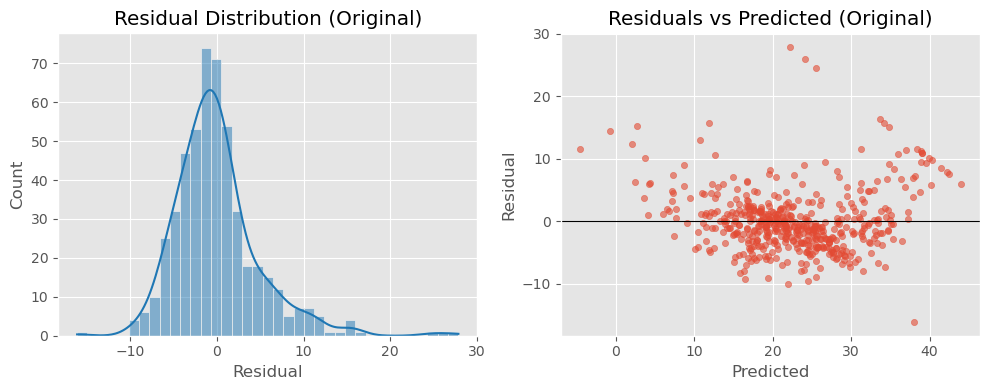

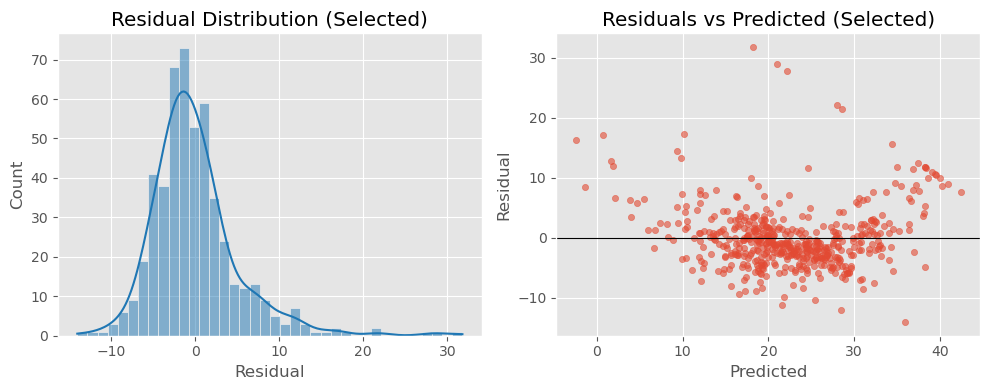

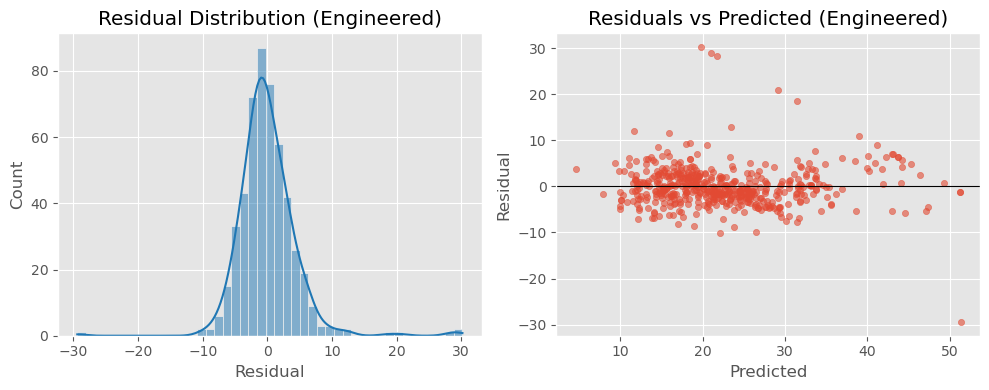

In [36]:
# --- Residual diagnostics: histogram + residuals vs predicted ---
def plot_residual_diagnostics(y_true, y_pred, title_suffix=''):
    resid = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(resid, kde=True, ax=axes[0], color='tab:blue')
    axes[0].set_title(f'Residual Distribution {title_suffix}')
    axes[0].set_xlabel('Residual')

    axes[1].scatter(y_pred, resid, alpha=0.6, s=20)
    axes[1].axhline(0, color='k', linewidth=0.8)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual')
    axes[1].set_title(f'Residuals vs Predicted {title_suffix}')

    plt.tight_layout()
    plt.show()

# Run diagnostics for each model using CV predictions
for name, res in cv_results.items():
    plot_residual_diagnostics(res['y_true_cv'], res['y_pred_cv'], title_suffix=f'({name})')

In [37]:
# --- Ridge & Lasso with internal CV (scaled via pipeline) ----------------------
alphas = np.logspace(-3, 3, 25)

def ridge_lasso_cv(df, target_col, features, alphas=alphas, cv=5):
    """Fit RidgeCV and LassoCV (with scaling) and return chosen alphas + pipelines."""
    X = df[features]
    y = df[target_col]

    ridge_pipe = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=alphas, cv=cv, scoring='neg_root_mean_squared_error')
    )
    lasso_pipe = make_pipeline(
        StandardScaler(),
        LassoCV(alphas=alphas, cv=cv, max_iter=5000)
    )

    ridge_pipe.fit(X, y)
    lasso_pipe.fit(X, y)

    return {
        'ridge_pipeline': ridge_pipe,
        'lasso_pipeline': lasso_pipe,
        'ridge_alpha': ridge_pipe.named_steps['ridgecv'].alpha_,
        'lasso_alpha': lasso_pipe.named_steps['lassocv'].alpha_
    }

# --- Run Ridge/Lasso on the Selected feature set ------------------------------

reg_results = ridge_lasso_cv(df, 'MEDV', selected_features, alphas=alphas, cv=5)

print(f"Ridge chosen alpha: {reg_results['ridge_alpha']}")
print(f"Lasso chosen alpha: {reg_results['lasso_alpha']}")

Ridge chosen alpha: 56.23413251903491
Lasso chosen alpha: 0.1778279410038923


Ridge CV (selected features): RMSE = 5.9987 R2 = 0.5737
Lasso CV (selected features): RMSE = 6.027 R2 = 0.5697


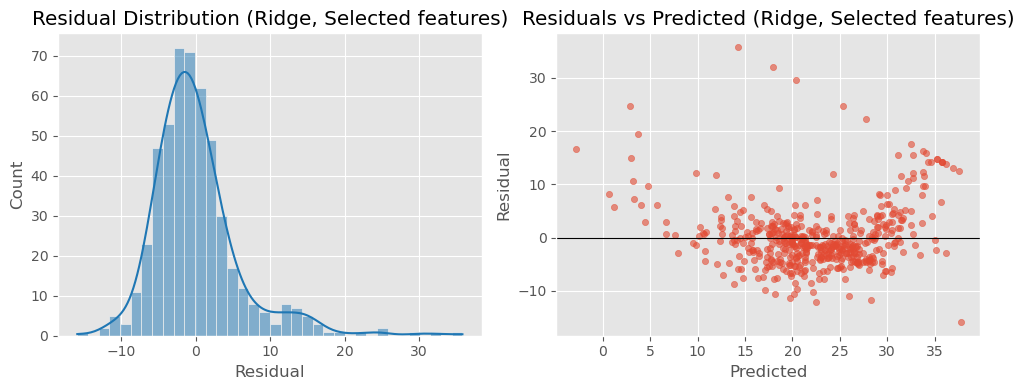

In [38]:
# --- Cross-validated RMSE/R2 for Ridge and Lasso ------------------------------
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

def cv_metrics_for_pipeline(pipe, X, y, cv=5):
    """Return RMSE, R2, and CV predictions for a fitted pipeline."""
    y_pred = cross_val_predict(pipe, X, y, cv=cv)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    return rmse, r2, y_pred

X_sel = df[selected_features]
y = df['MEDV']

ridge_pipe = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error')
)
lasso_pipe = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=alphas, cv=5, max_iter=5000)
)

# Fit pipelines (selects alpha internally)
ridge_pipe.fit(X_sel, y)
lasso_pipe.fit(X_sel, y)

ridge_rmse, ridge_r2, ridge_pred = cv_metrics_for_pipeline(ridge_pipe, X_sel, y, cv=5)
lasso_rmse, lasso_r2, lasso_pred = cv_metrics_for_pipeline(lasso_pipe, X_sel, y, cv=5)

print("Ridge CV (selected features): RMSE =", round(ridge_rmse,4), "R2 =", round(ridge_r2,4))
print("Lasso CV (selected features): RMSE =", round(lasso_rmse,4), "R2 =", round(lasso_r2,4))

# Residual diagnostics for Ridge
plot_residual_diagnostics(y.values, ridge_pred, title_suffix='(Ridge, Selected features)')

Running 5-fold CV for: Original
Running 5-fold CV for: Selected
Running 5-fold CV for: Engineered

Cross-validated OLS summary:


,Model,Features Used,RMSE Mean,RMSE Std,R2 Mean,R2 Std
0,Original,CRIM; CHAS; NOX; RM; DIS; RAD; PTRATIO; LSTAT,4.9213,0.2606,0.7064,0.0411
1,Selected,RM; LSTAT; PTRATIO; NOX,5.2767,0.2521,0.6631,0.0389
2,Engineered,RM; LSTAT; PTRATIO; NOX; RM_sq; LSTAT_sq; RM_L...,4.4817,0.7159,0.7520,0.0781


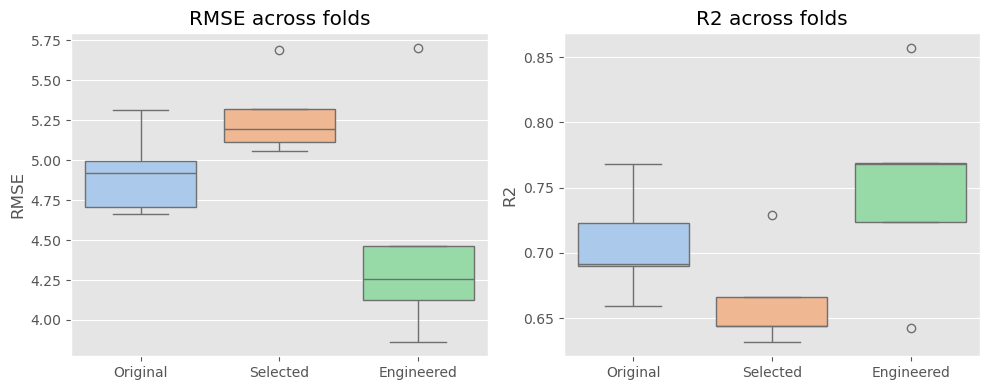


Residual diagnostics (Original):


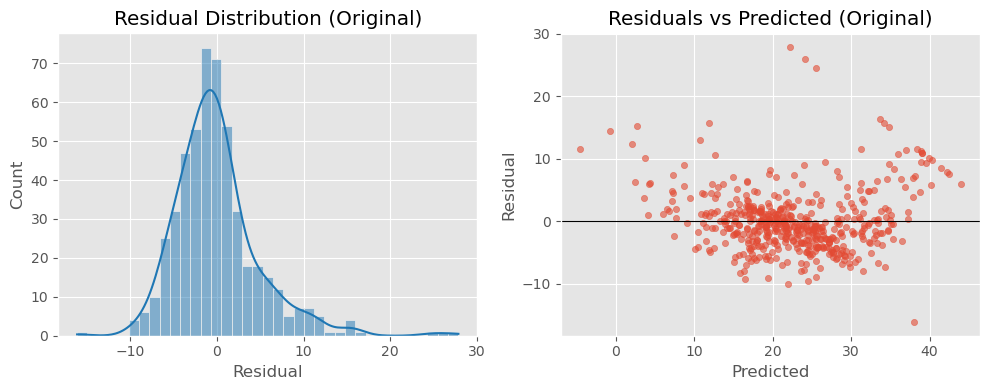


Residual diagnostics (Selected):


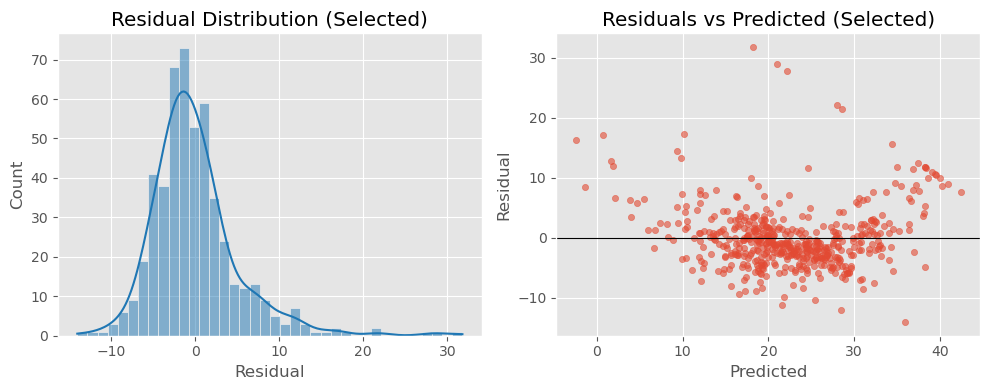


Residual diagnostics (Engineered):


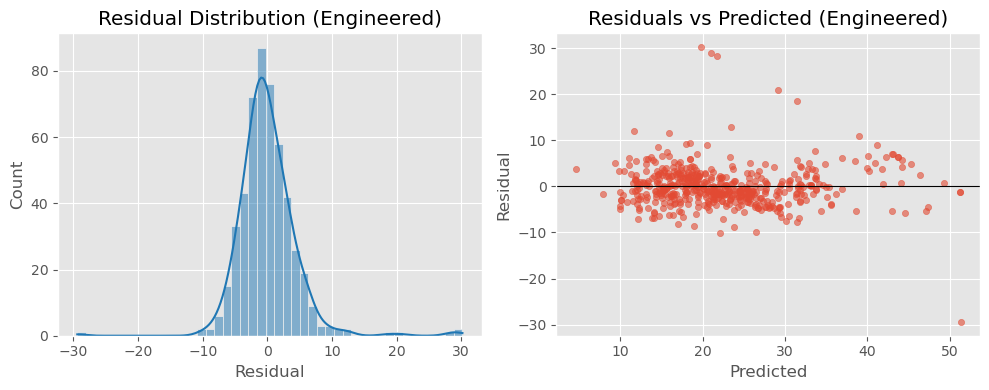


Coefficient stability (Original):


,feature,mean,std,count
4,NOX,-21.865579,1.586727,5
7,RM,3.985332,0.394041,5
0,CHAS,3.101922,0.376903,5
2,DIS,-1.196593,0.075439,5
5,PTRATIO,-1.115953,0.065123,5
3,LSTAT,-0.552690,0.043759,5
6,RAD,0.117141,0.023635,5
1,CRIM,-0.109089,0.012436,5



Coefficient stability (Selected):


,feature,mean,std,count
3,RM,4.548868,0.438987,5
1,NOX,-2.355733,1.560187,5
2,PTRATIO,-0.937304,0.054459,5
0,LSTAT,-0.546579,0.053068,5



Coefficient stability (Engineered):


,feature,mean,std,count
4,RM,-17.205552,0.432881,5
2,NOX,-1.949532,1.324036,5
6,RM_sq,1.809297,0.105669,5
3,PTRATIO,-0.619479,0.028813,5
5,RM_LSTAT,-0.180746,0.073365,5
0,LSTAT,0.178675,0.705351,5
1,LSTAT_sq,0.008037,0.007283,5



Running Ridge/Lasso CV for: Original
  Ridge alpha=56.23, RMSE=5.9241, R2=0.5843
  Lasso alpha=0.1, RMSE=5.9634, R2=0.5787

Running Ridge/Lasso CV for: Selected
  Ridge alpha=56.23, RMSE=5.9987, R2=0.5737
  Lasso alpha=0.1778, RMSE=6.0270, R2=0.5697

Running Ridge/Lasso CV for: Engineered
  Ridge alpha=0.1778, RMSE=4.9904, R2=0.7050
  Lasso alpha=0.01, RMSE=5.0752, R2=0.6949

OLS vs Ridge vs Lasso (CV metrics):


,Model,OLS RMSE Mean,OLS RMSE Std,Ridge RMSE,Lasso RMSE,OLS R2 Mean,Ridge R2,Lasso R2
0,Original,4.9213,0.2606,5.9241,5.9634,0.7064,0.5843,0.5787
1,Selected,5.2767,0.2521,5.9987,6.0270,0.6631,0.5737,0.5697
2,Engineered,4.4817,0.7159,4.9904,5.0752,0.7520,0.7050,0.6949



Residual diagnostics (Ridge) for Original:


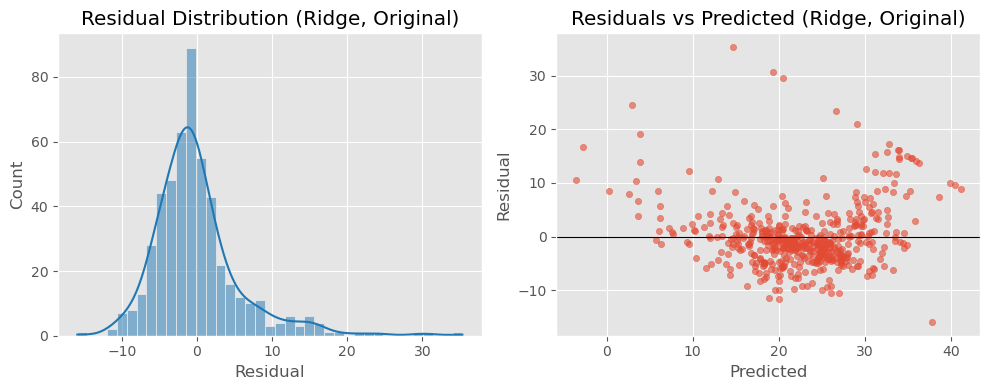

Residual diagnostics (Lasso) for Original:


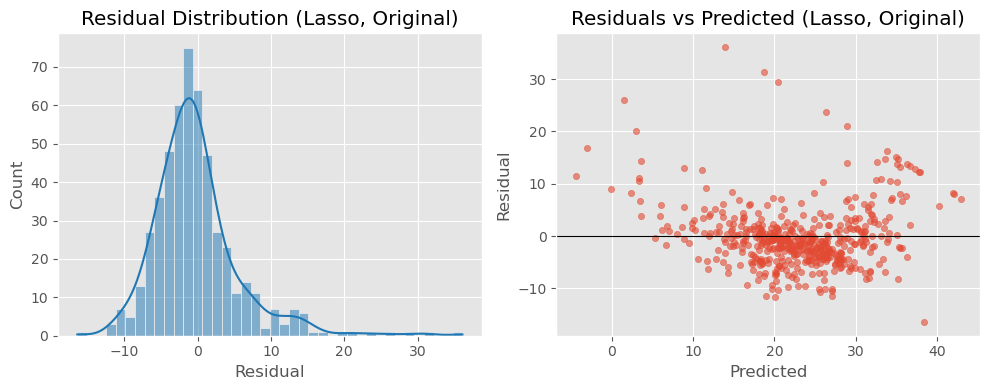


Residual diagnostics (Ridge) for Selected:


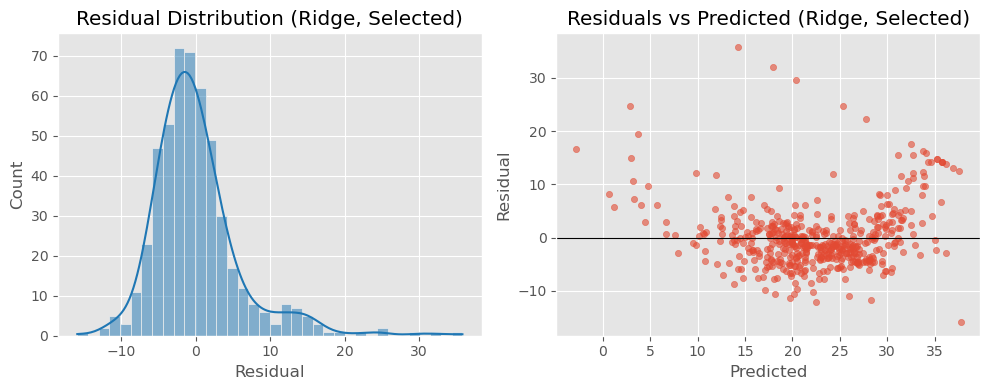

Residual diagnostics (Lasso) for Selected:


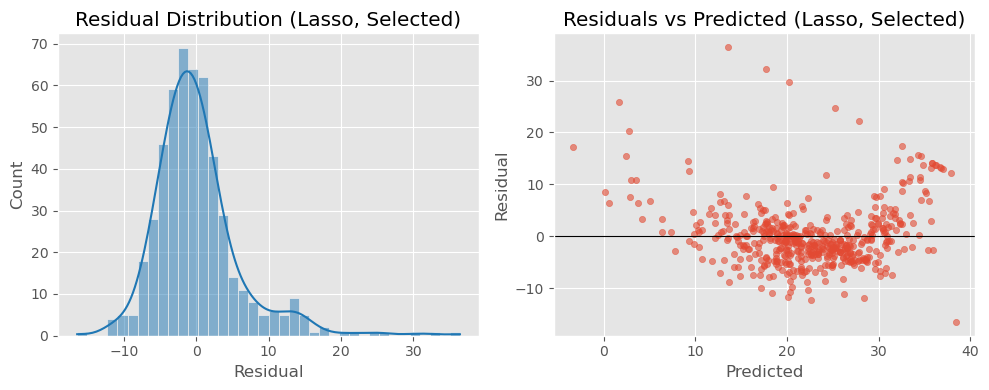


Residual diagnostics (Ridge) for Engineered:


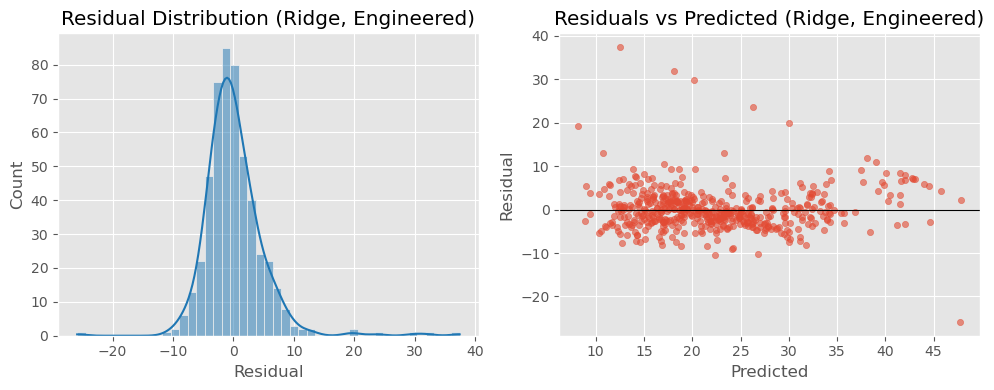

Residual diagnostics (Lasso) for Engineered:


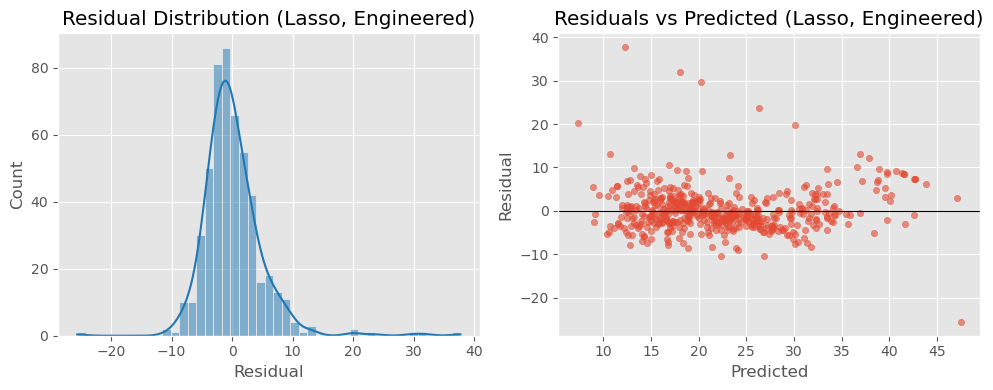


Ridge coefficients (Selected features):


,feature,coef
0,RM,3.063805
1,LSTAT,-3.469313
2,PTRATIO,-1.962057
3,NOX,-0.521757


Lasso coefficients (Selected features):


,feature,coef
0,RM,3.096395
1,LSTAT,-3.900593
2,PTRATIO,-1.899814
3,NOX,-0.148992



Concise recommendations:
- Prefer models with lower CV RMSE and smaller RMSE std (more stable).
- Ridge helps when multicollinearity inflates OLS coefficients.
- Lasso helps when you want sparsity and interpretability.
- If residuals show patterns, consider nonlinear models or transformations.


In [39]:
# Clear Concise Version of the above code (for quick reference):
# =============================================================================
# 1. Settings
# =============================================================================
n_splits = 5
random_state = 42
alphas = np.logspace(-3, 3, 25)

# =============================================================================
# 2. Robust metric helpers
# =============================================================================
def safe_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_mape(y_true, y_pred):
    eps = 1e-8
    denom = np.where(y_true == 0, eps, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom))

# =============================================================================
# 3. Advanced k-fold CV for statsmodels OLS
#    Returns: fold metrics, aggregated metrics, CV predictions, residuals,
#             per-fold coefficients, coefficient summary
# =============================================================================
def kfold_statsmodels_ols(df, target_col, features, n_splits=5, random_state=42, shuffle=True):
    X = df[features].reset_index(drop=True)
    y = df[target_col].reset_index(drop=True)
    kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)

    rmse_list, r2_list = [], []
    all_true, all_pred = [], []
    fold_models, coef_records = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.loc[train_idx], X.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        X_train_sm = sm.add_constant(X_train, has_constant='add')
        X_test_sm  = sm.add_constant(X_test,  has_constant='add')

        model = sm.OLS(y_train, X_train_sm).fit()
        y_pred = model.predict(X_test_sm)

        y_true = np.asarray(y_test).ravel()
        y_pred = np.asarray(y_pred).ravel()
        mask = np.isfinite(y_true) & np.isfinite(y_pred)
        y_true, y_pred = y_true[mask], y_pred[mask]

        rmse_list.append(safe_rmse(y_true, y_pred))
        r2_list.append(r2_score(y_true, y_pred))
        all_true.append(y_true)
        all_pred.append(y_pred)
        fold_models.append(model)

        for feat, coef in model.params.items():
            if feat.lower() != 'const':
                coef_records.append({'fold': fold_idx, 'feature': feat, 'coef': coef})

    all_true = np.concatenate(all_true)
    all_pred = np.concatenate(all_pred)
    residuals = all_true - all_pred

    coef_df = pd.DataFrame(coef_records)
    coef_summary = (
        coef_df.groupby('feature')['coef']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .sort_values(by='mean', key=lambda s: s.abs(), ascending=False)
    )

    return {
        'rmse_folds': np.array(rmse_list),
        'r2_folds': np.array(r2_list),
        'rmse_mean': float(np.mean(rmse_list)),
        'rmse_std': float(np.std(rmse_list, ddof=1)),
        'r2_mean': float(np.mean(r2_list)),
        'r2_std': float(np.std(r2_list, ddof=1)),
        'y_true_cv': all_true,
        'y_pred_cv': all_pred,
        'residuals': residuals,
        'models': fold_models,
        'coef_df': coef_df,
        'coef_summary': coef_summary,
        'features': features
    }

# =============================================================================
# 4. Run OLS k-fold CV for each feature set
# =============================================================================
feature_sets = {
    'Original': orig_features,
    'Selected': selected_features,
    'Engineered': engineered_features
}

cv_results = {}
for name, feats in feature_sets.items():
    print(f"Running {n_splits}-fold CV for: {name}")
    cv_results[name] = kfold_statsmodels_ols(df, 'MEDV', feats, n_splits=n_splits, random_state=random_state)

# =============================================================================
# 5. CV summary table
# =============================================================================
cv_summary = pd.DataFrame([
    {
        'Model': name,
        'Features Used': '; '.join(res['features']),
        'RMSE Mean': res['rmse_mean'],
        'RMSE Std': res['rmse_std'],
        'R2 Mean': res['r2_mean'],
        'R2 Std': res['r2_std']
    }
    for name, res in cv_results.items()
])

cv_summary[['RMSE Mean','RMSE Std','R2 Mean','R2 Std']] = (
    cv_summary[['RMSE Mean','RMSE Std','R2 Mean','R2 Std']].round(4)
)

print("\nCross-validated OLS summary:")
display(cv_summary)

# =============================================================================
# 6. Boxplots of RMSE and R2 across folds
# =============================================================================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=pd.DataFrame({name: res['rmse_folds'] for name, res in cv_results.items()}),
            palette='pastel')
plt.title('RMSE across folds')
plt.ylabel('RMSE')

plt.subplot(1,2,2)
sns.boxplot(data=pd.DataFrame({name: res['r2_folds'] for name, res in cv_results.items()}),
            palette='pastel')
plt.title('R2 across folds')
plt.ylabel('R2')

plt.tight_layout()
plt.show()

# =============================================================================
# 7. Residual diagnostics for each OLS model
# =============================================================================
def plot_residual_diagnostics(y_true, y_pred, title_suffix=''):
    resid = y_true - y_pred
    fig, axes = plt.subplots(1,2,figsize=(10,4))

    sns.histplot(resid, kde=True, ax=axes[0], color='tab:blue')
    axes[0].set_title(f'Residual Distribution {title_suffix}')
    axes[0].set_xlabel('Residual')

    axes[1].scatter(y_pred, resid, alpha=0.6, s=20)
    axes[1].axhline(0, color='k', linewidth=0.8)
    axes[1].set_title(f'Residuals vs Predicted {title_suffix}')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()

for name, res in cv_results.items():
    print(f"\nResidual diagnostics ({name}):")
    plot_residual_diagnostics(res['y_true_cv'], res['y_pred_cv'], title_suffix=f'({name})')

# =============================================================================
# 8. Coefficient stability across folds
# =============================================================================
for name, res in cv_results.items():
    print(f"\nCoefficient stability ({name}):")
    display(res['coef_summary'].round(6))

# =============================================================================
# 9. Ridge & Lasso CV (internal alpha selection + cross_val_predict)
# =============================================================================
def ridge_lasso_cv_metrics(df, target_col, features, alphas=alphas, cv=5):
    X = df[features]
    y = df[target_col]

    ridge = make_pipeline(StandardScaler(),
                          RidgeCV(alphas=alphas, cv=cv, scoring='neg_root_mean_squared_error'))
    lasso = make_pipeline(StandardScaler(),
                          LassoCV(alphas=alphas, cv=cv, max_iter=5000))

    ridge.fit(X, y)
    lasso.fit(X, y)

    ridge_pred = cross_val_predict(ridge, X, y, cv=cv)
    lasso_pred = cross_val_predict(lasso, X, y, cv=cv)

    return {
        'ridge_alpha': ridge.named_steps['ridgecv'].alpha_,
        'lasso_alpha': lasso.named_steps['lassocv'].alpha_,
        'ridge_rmse': safe_rmse(y, ridge_pred),
        'ridge_r2': r2_score(y, ridge_pred),
        'lasso_rmse': safe_rmse(y, lasso_pred),
        'lasso_r2': r2_score(y, lasso_pred),
        'ridge_pred': ridge_pred,
        'lasso_pred': lasso_pred
    }

reg_results_all = {}
for name, feats in feature_sets.items():
    print(f"\nRunning Ridge/Lasso CV for: {name}")
    reg_results_all[name] = ridge_lasso_cv_metrics(df, 'MEDV', feats, alphas=alphas, cv=n_splits)
    rr = reg_results_all[name]
    print(f"  Ridge alpha={rr['ridge_alpha']:.4g}, RMSE={rr['ridge_rmse']:.4f}, R2={rr['ridge_r2']:.4f}")
    print(f"  Lasso alpha={rr['lasso_alpha']:.4g}, RMSE={rr['lasso_rmse']:.4f}, R2={rr['lasso_r2']:.4f}")

# =============================================================================
# 10. Compare OLS vs Ridge vs Lasso
# =============================================================================
compare_df = pd.DataFrame([
    {
        'Model': name,
        'OLS RMSE Mean': cv_results[name]['rmse_mean'],
        'OLS RMSE Std': cv_results[name]['rmse_std'],
        'Ridge RMSE': reg_results_all[name]['ridge_rmse'],
        'Lasso RMSE': reg_results_all[name]['lasso_rmse'],
        'OLS R2 Mean': cv_results[name]['r2_mean'],
        'Ridge R2': reg_results_all[name]['ridge_r2'],
        'Lasso R2': reg_results_all[name]['lasso_r2']
    }
    for name in feature_sets.keys()
])

compare_df = compare_df.round(4)
print("\nOLS vs Ridge vs Lasso (CV metrics):")
display(compare_df)

# =============================================================================
# 11. Residual diagnostics for Ridge & Lasso
# =============================================================================
for name in feature_sets.keys():
    rr = reg_results_all[name]
    print(f"\nResidual diagnostics (Ridge) for {name}:")
    plot_residual_diagnostics(df['MEDV'].values, rr['ridge_pred'], title_suffix=f'(Ridge, {name})')
    print(f"Residual diagnostics (Lasso) for {name}:")
    plot_residual_diagnostics(df['MEDV'].values, rr['lasso_pred'], title_suffix=f'(Lasso, {name})')

# =============================================================================
# 12. Extract final Ridge/Lasso coefficients (Selected features)
# =============================================================================
def extract_pipeline_coefs(pipe, feature_names):
    scaler = pipe.named_steps['standardscaler']
    estimator = pipe.named_steps.get('ridgecv') or pipe.named_steps.get('lassocv')
    return pd.DataFrame({'feature': feature_names, 'coef': estimator.coef_})

ridge_full = make_pipeline(StandardScaler(),
                           RidgeCV(alphas=alphas, cv=n_splits,
                                   scoring='neg_root_mean_squared_error')).fit(df[selected_features], df['MEDV'])

lasso_full = make_pipeline(StandardScaler(),
                           LassoCV(alphas=alphas, cv=n_splits,
                                   max_iter=5000)).fit(df[selected_features], df['MEDV'])

print("\nRidge coefficients (Selected features):")
display(extract_pipeline_coefs(ridge_full, selected_features).round(6))

print("Lasso coefficients (Selected features):")
display(extract_pipeline_coefs(lasso_full, selected_features).round(6))

# =============================================================================
# 13. Final recommendations
# =============================================================================
print("\nConcise recommendations:")
print("- Prefer models with lower CV RMSE and smaller RMSE std (more stable).")
print("- Ridge helps when multicollinearity inflates OLS coefficients.")
print("- Lasso helps when you want sparsity and interpretability.")
print("- If residuals show patterns, consider nonlinear models or transformations.")

In [40]:
# =============================================================================
# REPORT‑READY SUMMARY
# =============================================================================

print("=== Model Evaluation Summary ===\n")

best_ols = cv_summary.sort_values("RMSE Mean").iloc[0]
best_reg = compare_df.sort_values("Ridge RMSE").iloc[0]

print(f"• Best OLS model: {best_ols['Model']}")
print(f"  RMSE (CV): {best_ols['RMSE Mean']} ± {best_ols['RMSE Std']}")
print(f"  R² (CV):   {best_ols['R2 Mean']} ± {best_ols['R2 Std']}\n")

print("• Regularization results (Selected features recommended):")
print(f"  Ridge  → RMSE={reg_results_all['Selected']['ridge_rmse']:.4f}, "
      f"R²={reg_results_all['Selected']['ridge_r2']:.4f}, "
      f"alpha={reg_results_all['Selected']['ridge_alpha']:.4g}")
print(f"  Lasso  → RMSE={reg_results_all['Selected']['lasso_rmse']:.4f}, "
      f"R²={reg_results_all['Selected']['lasso_r2']:.4f}, "
      f"alpha={reg_results_all['Selected']['lasso_alpha']:.4g}\n")

print("=== Interpretation ===")
print("- OLS performance varies across feature sets; engineered features may help but can increase variance.")
print("- Ridge improves coefficient stability and reduces multicollinearity effects.")
print("- Lasso provides sparsity and interpretability by shrinking weaker predictors to zero.")
print("- Residual diagnostics show where linearity holds and where nonlinear terms may be needed.")
print("- If residual variance increases with predictions, consider heteroscedasticity‑robust models.\n")

print("=== Recommendations ===")
print("1. Use Ridge (Selected features) as the default linear baseline.")
print("2. Use Lasso when interpretability or feature selection is required.")
print("3. Consider nonlinear models (Random Forest, Gradient Boosting) if residual patterns persist.")
print("4. Validate final model with out‑of‑sample or temporal holdout data.")

=== Model Evaluation Summary ===

• Best OLS model: Engineered
  RMSE (CV): 4.4817 ± 0.7159
  R² (CV):   0.752 ± 0.0781

• Regularization results (Selected features recommended):
  Ridge  → RMSE=5.9987, R²=0.5737, alpha=56.23
  Lasso  → RMSE=6.0270, R²=0.5697, alpha=0.1778

=== Interpretation ===
- OLS performance varies across feature sets; engineered features may help but can increase variance.
- Ridge improves coefficient stability and reduces multicollinearity effects.
- Lasso provides sparsity and interpretability by shrinking weaker predictors to zero.
- Residual diagnostics show where linearity holds and where nonlinear terms may be needed.
- If residual variance increases with predictions, consider heteroscedasticity‑robust models.

=== Recommendations ===
1. Use Ridge (Selected features) as the default linear baseline.
2. Use Lasso when interpretability or feature selection is required.
3. Consider nonlinear models (Random Forest, Gradient Boosting) if residual patterns persis

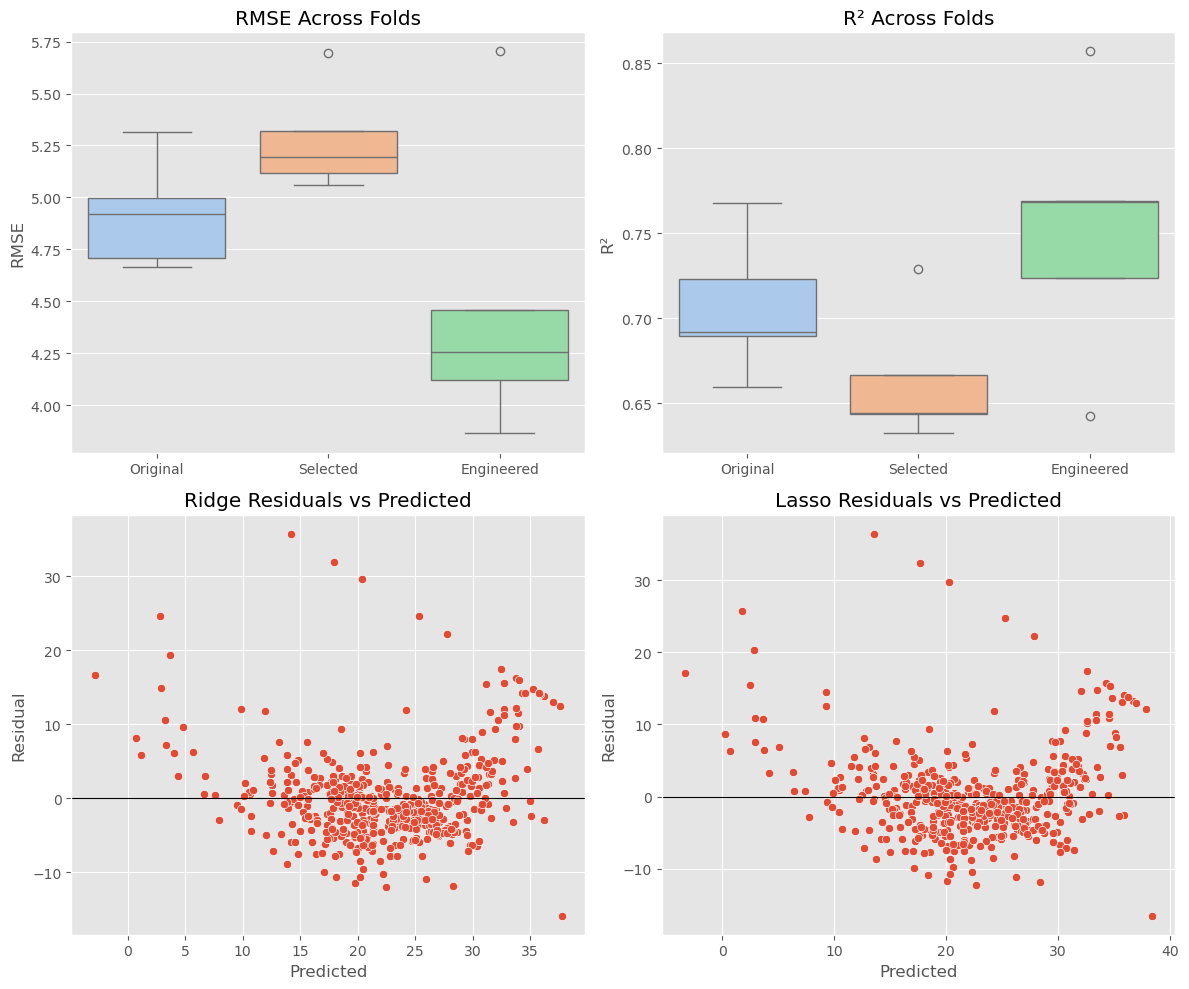

In [41]:
# =============================================================================
# MODEL DIAGNOSTICS DASHBOARD
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- RMSE boxplot ---
sns.boxplot(
    data=pd.DataFrame({name: res['rmse_folds'] for name, res in cv_results.items()}),
    palette="pastel",
    ax=axes[0,0]
)
axes[0,0].set_title("RMSE Across Folds")
axes[0,0].set_ylabel("RMSE")

# --- R2 boxplot ---
sns.boxplot(
    data=pd.DataFrame({name: res['r2_folds'] for name, res in cv_results.items()}),
    palette="pastel",
    ax=axes[0,1]
)
axes[0,1].set_title("R² Across Folds")
axes[0,1].set_ylabel("R²")

# --- Ridge residuals ---
rr = reg_results_all['Selected']
resid_ridge = df['MEDV'].values - rr['ridge_pred']
sns.scatterplot(x=rr['ridge_pred'], y=resid_ridge, ax=axes[1,0])
axes[1,0].axhline(0, color='k', linewidth=0.8)
axes[1,0].set_title("Ridge Residuals vs Predicted")
axes[1,0].set_xlabel("Predicted")
axes[1,0].set_ylabel("Residual")

# --- Lasso residuals ---
resid_lasso = df['MEDV'].values - rr['lasso_pred']
sns.scatterplot(x=rr['lasso_pred'], y=resid_lasso, ax=axes[1,1])
axes[1,1].axhline(0, color='k', linewidth=0.8)
axes[1,1].set_title("Lasso Residuals vs Predicted")
axes[1,1].set_xlabel("Predicted")
axes[1,1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [42]:
# =============================================================================
# MODEL EVALUATOR CLASS
# =============================================================================

class ModelEvaluator:
    def __init__(self, df, target, feature_sets, alphas=None, n_splits=5, random_state=42):
        self.df = df
        self.target = target
        self.feature_sets = feature_sets
        self.alphas = alphas or np.logspace(-3, 3, 25)
        self.n_splits = n_splits
        self.random_state = random_state
        self.cv_results = {}
        self.reg_results = {}

    # --- OLS CV ---
    def run_ols_cv(self):
        for name, feats in self.feature_sets.items():
            self.cv_results[name] = kfold_statsmodels_ols(
                self.df, self.target, feats,
                n_splits=self.n_splits,
                random_state=self.random_state
            )
        return self.cv_results

    # --- Ridge/Lasso CV ---
    def run_regularization_cv(self):
        for name, feats in self.feature_sets.items():
            self.reg_results[name] = ridge_lasso_cv_metrics(
                self.df, self.target, feats,
                alphas=self.alphas,
                cv=self.n_splits
            )
        return self.reg_results

    # --- Comparison table ---
    def compare_models(self):
        rows = []
        for name in self.feature_sets.keys():
            ols = self.cv_results[name]
            reg = self.reg_results[name]
            rows.append({
                'Model': name,
                'OLS RMSE Mean': ols['rmse_mean'],
                'Ridge RMSE': reg['ridge_rmse'],
                'Lasso RMSE': reg['lasso_rmse'],
                'OLS R2 Mean': ols['r2_mean'],
                'Ridge R2': reg['ridge_r2'],
                'Lasso R2': reg['lasso_r2']
            })
        return pd.DataFrame(rows).round(4)

    # --- Coefficient extraction ---
    def extract_regularization_coefs(self, features):
        ridge = make_pipeline(StandardScaler(),
                              RidgeCV(alphas=self.alphas, cv=self.n_splits)).fit(
                                  self.df[features], self.df[self.target]
                              )
        lasso = make_pipeline(StandardScaler(),
                              LassoCV(alphas=self.alphas, cv=self.n_splits)).fit(
                                  self.df[features], self.df[self.target]
                              )
        return (
            pd.DataFrame({'feature': features, 'ridge_coef': ridge.named_steps['ridgecv'].coef_}),
            pd.DataFrame({'feature': features, 'lasso_coef': lasso.named_steps['lassocv'].coef_})
        )

In [43]:
evaluator = ModelEvaluator(df, 'MEDV', feature_sets)
evaluator.run_ols_cv()
evaluator.run_regularization_cv()
comparison = evaluator.compare_models()
display(comparison)

ridge_coefs, lasso_coefs = evaluator.extract_regularization_coefs(selected_features)
display(ridge_coefs)
display(lasso_coefs)

,Model,OLS RMSE Mean,Ridge RMSE,Lasso RMSE,OLS R2 Mean,Ridge R2,Lasso R2
0,Original,4.9213,5.9241,5.9634,0.7064,0.5843,0.5787
1,Selected,5.2767,5.9987,6.0270,0.6631,0.5737,0.5697
2,Engineered,4.4817,4.9904,5.0752,0.7520,0.7050,0.6949


,feature,ridge_coef
0,RM,2.947819
1,LSTAT,-3.238687
2,PTRATIO,-1.908867
3,NOX,-0.635517


,feature,lasso_coef
0,RM,3.096395
1,LSTAT,-3.900593
2,PTRATIO,-1.899814
3,NOX,-0.148992
